In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.stattools import durbin_watson

In [2]:
# ALC
training_set = pd.read_csv("../data/training_data_v2.csv")
test_set = pd.read_csv("../data/test_data_v2.csv")

In [3]:
# ALC
# start with features coefs reduced to 0 in lasso regression
features_to_drop = ['num_slow_zones_sqrt', 'day_of_week_Saturday', 
                'day_of_week_Thursday', 'month_March', 
                'month_November', 'slow_zones_7day_avg', 
                'slow_zones_x_blue', 'slow_zones_x_red', 
                'infrastructure_stress_pc2', 'service_quality_cluster_0',
                # now for features we already used unsupervised methods on
                # and some of their transformations which re-introduce
                # strong multi-collinearity
               'total_track_pct', 'total_miles_affected',
               'alert_effect_shuttle', 'num_alerts', 'alert_effect_delay',
               'num_slow_zones', 'otp_score', 'total_track_pct_log',
                'alert_effect_shuttle_log',
               # additional variables with extremely high correlations to others
               'slow_zones_x_orange', 'slow_zones_x_green',
               'otp_score_lag1', 'num_alerts_log',
               'slow_zones_x_weekend', 'infrastructure_stress_pc1',
               'alert_effect_delay_log', 
                # standard to drop one of our one-hot encoded fixed effects columns
                'line_blue']

test_set = test_set.drop(features_to_drop, axis = 1)
training_set = training_set.drop(features_to_drop, axis = 1)

In [4]:
# ALC
# outcome variable
y_train = training_set['est_ridership']
training_set = training_set.drop('est_ridership', axis = 1)

y_test = test_set['est_ridership']
test_set = test_set.drop('est_ridership', axis = 1)

In [5]:
# ALC
# we need to prepare a little, we want numeric columns.
# our dates have a natural order so let's change to timestamp (continuous)
training_set['service_date'] = training_set['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())
test_set['service_date'] = test_set['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())

# this will only be the rolling avgs
training_set = training_set.fillna(training_set.mean())
test_set = test_set.fillna(test_set.mean())

# found another highly skewed one
training_set['otp_score_7day_avg_log'] = np.log1p(training_set['otp_score_7day_avg'])
test_set['otp_score_7day_avg_log'] = np.log1p(test_set['otp_score_7day_avg'])
training_set = training_set.drop('otp_score_7day_avg', axis = 1)
test_set = test_set.drop('otp_score_7day_avg', axis = 1)

In [6]:
# ALC
# fit
model = LinearRegression()
model.fit(training_set, y_train)

LinearRegression()

In [7]:
# ALC
# predict
y_pred = model.predict(test_set)

In [8]:
# ALC
print("Test RMSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

Test RMSE: 137481961.28128824
Test R2: 0.7866281383709098


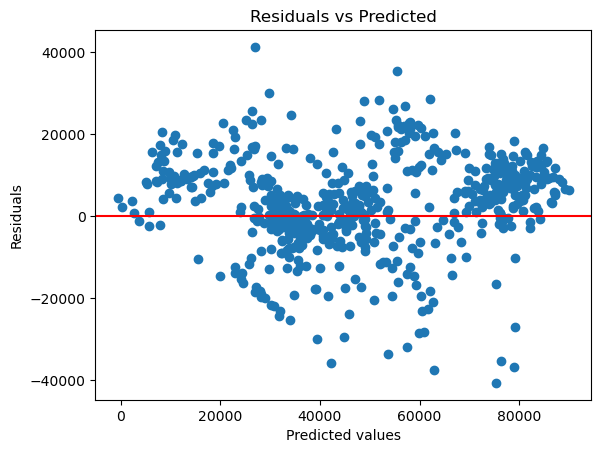

In [9]:
# ALC
import matplotlib.pyplot as plt
# calculate residuals
residuals = y_test - y_pred
# plot
plt.scatter(y_pred, residuals)
plt.axhline(y = 0, color='red')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [10]:
# ALC
# jarque-bera test
# if the p-value is small it means our data may not be suited to OLS
# or we need to work on the data more
jb, jb_p = jarque_bera(residuals)
print([jb, jb_p])

[68.47911726466636, 1.3488033103801583e-15]


In [11]:
# ALC
# autocorrelation test
dw_result = durbin_watson(residuals)
print(dw_result)

1.5310242886157073
